# Cox-Time

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn_pandas import DataFrameMapper
import torch
import torchtuples as tt

from pycox.models.cox_time import MLPVanillaCoxTime
from pycox.models import CoxTime
from pycox.evaluation import EvalSurv

In [2]:
SEED = 50

In [3]:
np.random.seed(SEED)
_ = torch.manual_seed(SEED)

## Dataset

In [ ]:
from dataset_11t5g_markov import DatasetMarkovSurvSurf

ds_name = 'markov_32feat_11t5g_less_balanced'
ds_df_dir = '/home/yc366/repos/survsurf_benchmark/dataset_split'
project = 'SurvSurfBenchmark_Markov_imbalanced'
SAVE_PATH = f'./pycox_models/{project}/cox_time_pycox_{SEED}'
g_resol = 1
t_resol = 1
split = 'train'
ds = DatasetMarkovSurvSurf(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    split=split, 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False
)
df_train = ds._get_df_Xy_trans_obs()

split = 'test'
ds = DatasetMarkovSurvSurf(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    split=split, 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False
)
df_test = ds._get_df_Xy_true_prob()

split = 'val'
ds = DatasetMarkovSurvSurf(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    split=split, 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False
)
df_val = ds._get_df_Xy_trans_obs()

In [5]:
df_test

,subject,g_max_by_time,duration,event_observed,feat00,feat01,feat02,feat03,feat04,feat05,...,feat24,feat25,feat26,feat27,feat28,feat29,feat30,feat31,weight,is_t_trans
0,1,1,0,0.000000e+00,0.932866,2.059838,-0.934938,-1.612990,0.527070,-1.551101,...,-0.219661,1.503398,-1.482385,-0.856164,-0.828693,0.114048,0.527728,1.0,1,NaN
1,1,2,0,0.000000e+00,0.932866,2.059838,-0.934938,-1.612990,0.527070,-1.551101,...,-0.219661,1.503398,-1.482385,-0.856164,-0.828693,0.114048,0.527728,1.0,1,NaN
2,1,3,0,0.000000e+00,0.932866,2.059838,-0.934938,-1.612990,0.527070,-1.551101,...,-0.219661,1.503398,-1.482385,-0.856164,-0.828693,0.114048,0.527728,1.0,1,NaN
3,1,4,0,0.000000e+00,0.932866,2.059838,-0.934938,-1.612990,0.527070,-1.551101,...,-0.219661,1.503398,-1.482385,-0.856164,-0.828693,0.114048,0.527728,1.0,1,NaN
4,1,5,0,0.000000e+00,0.932866,2.059838,-0.934938,-1.612990,0.527070,-1.551101,...,-0.219661,1.503398,-1.482385,-0.856164,-0.828693,0.114048,0.527728,1.0,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,1997,1,11,2.330460e-02,-1.125586,-1.053630,0.577824,0.072874,0.697798,-0.536877,...,0.509238,-0.682585,0.194751,0.176762,0.202325,-0.664899,0.061451,1.0,1,NaN
29996,1997,2,11,2.335599e-06,-1.125586,-1.053630,0.577824,0.072874,0.697798,-0.536877,...,0.509238,-0.682585,0.194751,0.176762,0.202325,-0.664899,0.061451,1.0,1,NaN
29997,1997,3,11,5.759814e-11,-1.125586,-1.053630,0.577824,0.072874,0.697798,-0.536877,...,0.509238,-0.682585,0.194751,0.176762,0.202325,-0.664899,0.061451,1.0,1,NaN
29998,1997,4,11,5.954643e-15,-1.125586,-1.053630,0.577824,0.072874,0.697798,-0.536877,...,0.509238,-0.682585,0.194751,0.176762,0.202325,-0.664899,0.061451,1.0,1,NaN


In [6]:
df_train.head()

,subject,event_observed,duration,g_max_by_time,feat00,feat01,feat02,feat03,feat04,feat05,...,feat24,feat25,feat26,feat27,feat28,feat29,feat30,feat31,weight,is_t_trans
0,0,0,8,1.0,0.883893,0.195865,0.357537,-2.343262,-1.084833,0.559696,...,-0.243339,-0.130031,-0.109017,1.556186,0.128778,-2.066949,-0.885493,0.0,1,1
1,2,1,2,1.0,1.301429,-0.994802,2.094665,0.359429,0.691002,-1.485720,...,-0.938910,-1.901464,1.095433,-0.333544,-1.441849,-1.416667,-1.629502,0.0,1,1
2,2,0,9,2.0,1.301429,-0.994802,2.094665,0.359429,0.691002,-1.485720,...,-0.938910,-1.901464,1.095433,-0.333544,-1.441849,-1.416667,-1.629502,0.0,1,1
3,4,0,10,1.0,-0.105813,2.009902,0.011231,-1.089429,-1.514511,-0.559761,...,-1.941266,0.341435,1.862855,-0.295230,0.478317,-0.715190,1.237293,1.0,1,1
4,6,1,7,1.0,0.805669,-0.012551,-0.260823,-0.889478,-1.615899,-0.851965,...,-0.708124,1.414139,-0.490533,1.181171,-0.046925,-1.460106,-0.508191,0.0,1,1


## Feature transforms

In [7]:
x_train = df_train.loc[:,df_train.columns.str.startswith('feat')|df_train.columns.str.startswith('g_max_by_time')].astype('float32')
x_train['g_max_by_time'] = x_train['g_max_by_time']/ds.g_max
x_train = x_train.values

x_val = df_val.loc[:,df_val.columns.str.startswith('feat')|df_val.columns.str.startswith('g_max_by_time')].astype('float32')
x_val['g_max_by_time'] = x_val['g_max_by_time']/ds.g_max
x_val = x_val.values

x_test = df_test.loc[:,df_test.columns.str.startswith('feat')|df_test.columns.str.startswith('g_max_by_time')].drop_duplicates().astype('float32')
x_test['g_max_by_time'] = x_test['g_max_by_time']/ds.g_max
x_test = x_test.values



In [8]:
df_train.loc[:,df_train.columns.str.startswith('feat')|df_train.columns.str.startswith('g_max_by_time')].columns == (
    df_test.loc[:,df_test.columns.str.startswith('feat')|df_test.columns.str.startswith('g_max_by_time')].columns
)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True])

We need no label transforms

In [9]:
get_target = lambda df: (df['duration'].astype('float32').values, df['event_observed'].astype('float32').values)
y_train = get_target(df_train)
y_val = get_target(df_val)
durations_test, events_test = get_target(df_test)
val = tt.tuplefy(x_val, y_val)

In [10]:
val.shapes()

((730, 33), ((730,), (730,)))

With `TupleTree` (the results of `tt.tuplefy`) we can easily repeat the validation dataset multiple times. This will be useful for reduce the variance of the validation loss, as the validation loss of `CoxTime` is not deterministic.

In [11]:
val.repeat(2).cat().shapes()

((1460, 33), ((1460,), (1460,)))

## Neural net
 
We create a simple MLP with two hidden layers, ReLU activations, batch norm and dropout. 
The net required by `CoxTime` is slightly different than most of the other methods as it also take `time` and an additional input argument. 
We have therefore crated the `MLPVanillaCoxTime` class that is a suitable version of `tt.practical.MLPVanilla`.
This class also removes the options for setting `out_features` and `output_bias` as they should be `1` and `False`, respectively.
 
To see the code for the networks call `??MLPVanillaCoxTime`.

In [12]:
in_features = x_train.shape[1]
num_nodes = [32, 32, 32, 32]
batch_norm = False
dropout = 0

net = MLPVanillaCoxTime(in_features, num_nodes, batch_norm, dropout)

## Training the model

In [13]:
model = CoxTime(net, tt.optim.Adam(lr=1e-2, weight_decay=1e-2))

In [14]:
batch_size = 16

We include the `EarlyStopping` callback to stop training when the validation loss stops improving. After training, this callback will also load the best performing model in terms of validation loss.

In [15]:
epochs = 2000
callbacks = [tt.callbacks.EarlyStopping(patience=500)]
verbose = True

In [16]:
%%time
log = model.fit(x_train, y_train, batch_size, epochs, callbacks, verbose,
                val_data=val.repeat(10).cat())

0:	[0s / 0s],		train_loss: 0.7137,	val_loss: 0.6707
1:	[0s / 0s],		train_loss: 0.6343,	val_loss: 0.6284
2:	[0s / 0s],		train_loss: 0.6277,	val_loss: 0.6253
3:	[0s / 0s],		train_loss: 0.6562,	val_loss: 0.6124
4:	[0s / 0s],		train_loss: 0.5905,	val_loss: 0.6050
5:	[0s / 1s],		train_loss: 0.6158,	val_loss: 0.5777
6:	[0s / 1s],		train_loss: 0.5860,	val_loss: 0.5919
7:	[0s / 1s],		train_loss: 0.5969,	val_loss: 0.5904
8:	[0s / 1s],		train_loss: 0.5860,	val_loss: 0.5916
9:	[0s / 1s],		train_loss: 0.5841,	val_loss: 0.5996
10:	[0s / 1s],		train_loss: 0.5687,	val_loss: 0.5925
11:	[0s / 1s],		train_loss: 0.5672,	val_loss: 0.5860
12:	[0s / 1s],		train_loss: 0.5575,	val_loss: 0.5783
13:	[0s / 2s],		train_loss: 0.5654,	val_loss: 0.5826
14:	[0s / 2s],		train_loss: 0.5436,	val_loss: 0.5827
15:	[0s / 2s],		train_loss: 0.5242,	val_loss: 0.5743
16:	[0s / 2s],		train_loss: 0.5526,	val_loss: 0.5878
17:	[0s / 2s],		train_loss: 0.5633,	val_loss: 0.5851
18:	[0s / 2s],		train_loss: 0.5819,	val_loss: 0.5908
19:

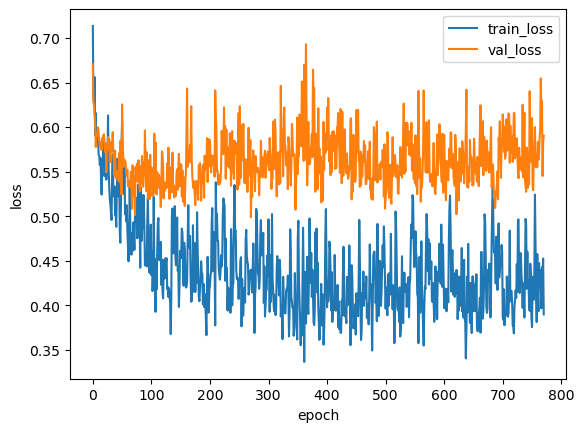

In [17]:
_ = log.plot()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.savefig(f'{SAVE_PATH}_training_curves.pdf')
log.to_pandas().to_csv(f'{SAVE_PATH}_training_curves.csv')

We can get the partial log-likelihood

In [18]:
model.partial_log_likelihood(*val).mean()

-6.101153

## Prediction

For evaluation we first need to obtain survival estimates for the test set.
This can be done with `model.predict_surv` which returns an array of survival estimates, or with `model.predict_surv_df` which returns the survival estimates as a dataframe.

However, as `CoxCC` is semi-parametric, we first need to get the non-parametric baseline hazard estimates with `compute_baseline_hazards`. 

Note that for large datasets the `sample` argument can be used to estimate the baseline hazard on a subset.

In [19]:
_ = model.compute_baseline_hazards()

In [20]:
x_test.shape

(2500, 33)

In [21]:
x_test

array([[ 0.2       ,  0.93286633,  2.059838  , ...,  0.1140476 ,
         0.5277285 ,  1.        ],
       [ 0.4       ,  0.93286633,  2.059838  , ...,  0.1140476 ,
         0.5277285 ,  1.        ],
       [ 0.6       ,  0.93286633,  2.059838  , ...,  0.1140476 ,
         0.5277285 ,  1.        ],
       ...,
       [ 0.6       , -1.1255862 , -1.0536298 , ..., -0.6648991 ,
         0.06145128,  1.        ],
       [ 0.8       , -1.1255862 , -1.0536298 , ..., -0.6648991 ,
         0.06145128,  1.        ],
       [ 1.        , -1.1255862 , -1.0536298 , ..., -0.6648991 ,
         0.06145128,  1.        ]], dtype=float32)

In [22]:
surv = model.predict_surv_df(x_test)

In [23]:
surv

,0,1,2,3,4,5,6,7,8,9,...,2490,2491,2492,2493,2494,2495,2496,2497,2498,2499
duration,,,,,,,,,,,,,,,,,,,,,
1.0,0.845423,0.960471,0.990328,0.997467,0.999304,0.856036,0.957968,0.988208,0.996728,0.999095,...,0.958449,0.989995,0.997620,0.999436,0.999866,0.981922,0.995073,0.998648,0.999626,0.999897
2.0,0.750696,0.930951,0.981636,0.994856,0.998545,0.767005,0.927195,0.978693,0.994039,0.998350,...,0.914585,0.977219,0.994130,0.998590,0.999666,0.957842,0.987708,0.996431,0.999008,0.999725
3.0,0.694854,0.909238,0.974214,0.992508,0.997844,0.694488,0.900215,0.970138,0.991448,0.997575,...,0.878577,0.965859,0.990752,0.997601,0.999367,0.906574,0.971183,0.991323,0.997473,0.999266
4.0,0.653055,0.891276,0.967983,0.990462,0.997182,0.626874,0.873213,0.961393,0.988730,0.996735,...,0.846671,0.955513,0.987651,0.996645,0.999049,0.830164,0.943214,0.981756,0.994268,0.998219
5.0,0.630143,0.881097,0.964413,0.989286,0.996801,0.583924,0.852885,0.953951,0.986375,0.996006,...,0.827257,0.949083,0.985615,0.995963,0.998822,0.779527,0.923718,0.974974,0.991983,0.997457
6.0,0.614729,0.873883,0.961785,0.988390,0.996501,0.549924,0.836073,0.947668,0.984214,0.995281,...,0.813150,0.944107,0.983897,0.995386,0.998630,0.739144,0.907553,0.969278,0.990056,0.996813
7.0,0.603936,0.868760,0.959910,0.987750,0.996287,0.526749,0.824211,0.943185,0.982667,0.994762,...,0.803959,0.940552,0.982666,0.994973,0.998493,0.711456,0.896126,0.965211,0.988675,0.996352
8.0,0.592914,0.863464,0.957963,0.987085,0.996064,0.503609,0.812013,0.938529,0.981054,0.994220,...,0.794480,0.936858,0.981383,0.994542,0.998349,0.683672,0.884357,0.960985,0.987237,0.995870
9.0,0.582886,0.858588,0.956164,0.986469,0.995858,0.483017,0.800840,0.934224,0.979558,0.993716,...,0.785772,0.933437,0.980192,0.994141,0.998216,0.658826,0.873559,0.957075,0.985902,0.995423


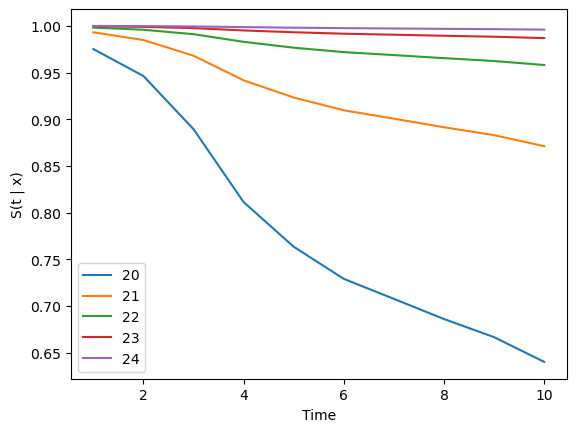

In [24]:
n = 5
surv.iloc[:, 5*(n-1):5*n].plot()
plt.ylabel('S(t | x)')
_ = plt.xlabel('Time')

In [25]:
model.save_net(SAVE_PATH)